# Jupyter Notebook Exercises

Welcome to the lab notebook! This notebook addresses the exercises from Phase 0, Lesson 05: **Jupyter Notebooks**.

Here we will explore:
1. **Performance benchmarking** using `%timeit` (List Comprehension vs. NumPy).
2. **Data processing & visualization** (CSV creation, DataFrame loading, and plotting).
3. **Notebook tips & tricks** ready for cloud GPU platforms like Google Colab.

---  
## Exercise 1: `%timeit` Benchmarking (List vs. NumPy)

We compare the creation of an array of 100,000 random numbers using a Python list comprehension (stdlib `random`) vs. NumPy.

In [1]:
import random
import numpy as np

print("=== Benchmarking List Comprehension ===")
%timeit [random.random() for _ in range(100000)]

print("\n=== Benchmarking NumPy ===")
%timeit np.random.random(100000)

=== Benchmarking List Comprehension ===


8.36 ms ± 250 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

=== Benchmarking NumPy ===


841 μs ± 20 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


---  
## Exercise 2: Load CSV, Display DataFrame & Plot a Chart

We'll generate a mock CSV containing training metrics (loss and accuracy over 10 epochs), load it using Pandas, display the table nicely, and plot the learning curves using Matplotlib.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure plots are displayed inline in the notebook
%matplotlib inline

# 1. Generate and save a mock CSV
metrics_df = pd.DataFrame({
    "epoch": np.arange(1, 11),
    "loss": [0.92, 0.68, 0.45, 0.32, 0.25, 0.19, 0.15, 0.12, 0.09, 0.07],
    "accuracy": [0.55, 0.71, 0.82, 0.88, 0.91, 0.93, 0.95, 0.96, 0.98, 0.99]
})
metrics_df.to_csv("training_history.csv", index=False)
print("Mock CSV 'training_history.csv' successfully created!")

Mock CSV 'training_history.csv' successfully created!


In [3]:
# 2. Load the CSV and display the DataFrame
df = pd.read_csv("training_history.csv")
df

,epoch,loss,accuracy
0,1,0.92,0.55
1,2,0.68,0.71
2,3,0.45,0.82
3,4,0.32,0.88
4,5,0.25,0.91
5,6,0.19,0.93
6,7,0.15,0.95
7,8,0.12,0.96
8,9,0.09,0.98
9,10,0.07,0.99


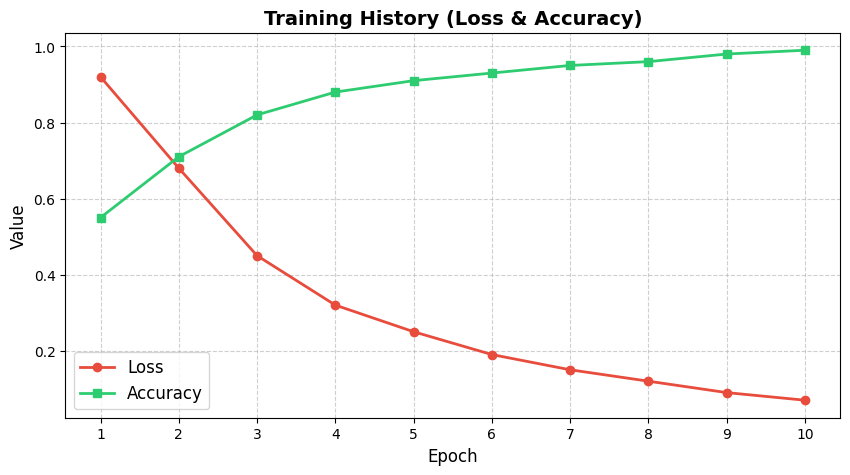

In [4]:
# 3. Plot the loaded metrics
plt.figure(figsize=(10, 5))

plt.plot(df["epoch"], df["loss"], label="Loss", color="#e74c3c", marker="o", linewidth=2)
plt.plot(df["epoch"], df["accuracy"], label="Accuracy", color="#2ecc71", marker="s", linewidth=2)

plt.title("Training History (Loss & Accuracy)", fontsize=14, fontweight="bold")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.xticks(df["epoch"])
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)

plt.show()

---  
## Exercise 3: Colab GPU & Notebook Tips Demo

Below is the complete demo code adapted from `code/notebook_tips.py`. 

> **Colab GPU Setup Instructions:**
> 1. Open [colab.research.google.com](https://colab.research.google.com).
> 2. Click **File > Upload Notebook** and select this `.ipynb` file.
> 3. Go to **Runtime > Change runtime type** and select **T4 GPU** (or any other available free GPU tier).
> 4. Click **Connect** on the top right, then run the cells!

=== Timing: List vs NumPy ===

List comprehension: 0.1674s
NumPy:              0.0119s
Speedup:            14.0x

=== Inline Plotting ===



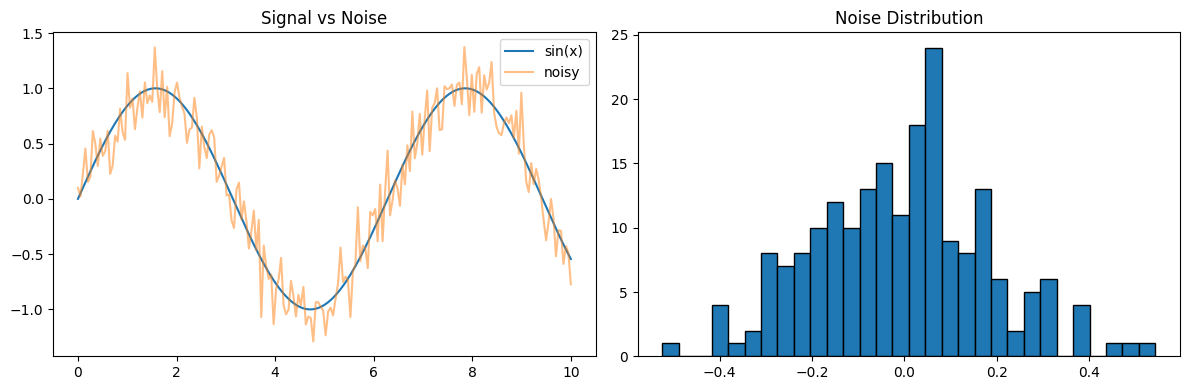


=== DataFrame Display ===



,model,accuracy,train_time_sec,parameters
0,Linear Regression,0.72,0.1,102
1,Random Forest,0.89,2.3,50000
2,Neural Network,0.94,45.6,1200000
3,XGBoost,0.91,8.2,25000



=== Memory Usage ===



Array   1K elements:     0.01 MB
Array 100K elements:     0.80 MB
Array  10M elements:    80.00 MB

Python process memory: ~80.0 MB for the large array


In [5]:
import time
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Timing Comparison
print("=== Timing: List vs NumPy ===\n")
size = 1_000_000

start = time.perf_counter()
python_list = [x ** 2 for x in range(size)]
list_time = time.perf_counter() - start
print(f"List comprehension: {list_time:.4f}s")

start = time.perf_counter()
numpy_array = np.arange(size) ** 2
numpy_time = time.perf_counter() - start
print(f"NumPy:              {numpy_time:.4f}s")
print(f"Speedup:            {list_time / numpy_time:.1f}x")

# 2. Inline Plotting
print("\n=== Inline Plotting ===\n")
np.random.seed(42)
x = np.linspace(0, 10, 200)
y_sin = np.sin(x)
y_noisy = y_sin + np.random.normal(0, 0.2, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x, y_sin, label="sin(x)")
axes[0].plot(x, y_noisy, alpha=0.5, label="noisy")
axes[0].set_title("Signal vs Noise")
axes[0].legend()

axes[1].hist(y_noisy - y_sin, bins=30, edgecolor="black")
axes[1].set_title("Noise Distribution")
plt.tight_layout()
plt.show()

# 3. DataFrame Display
print("\n=== DataFrame Display ===\n")
df_tips = pd.DataFrame({
    "model": ["Linear Regression", "Random Forest", "Neural Network", "XGBoost"],
    "accuracy": [0.72, 0.89, 0.94, 0.91],
    "train_time_sec": [0.1, 2.3, 45.6, 8.2],
    "parameters": [102, 50_000, 1_200_000, 25_000],
})
display(df_tips)

# 4. Memory Check
print("\n=== Memory Usage ===\n")
small = np.random.randn(1000)
medium = np.random.randn(100_000)
large = np.random.randn(10_000_000)

for name, arr in [("1K", small), ("100K", medium), ("10M", large)]:
    size_mb = arr.nbytes / 1e6
    print(f"Array {name:>4s} elements: {size_mb:>8.2f} MB")

print(f"\nPython process memory: ~{sys.getsizeof(large) / 1e6:.1f} MB for the large array")